In [1]:
import lamindb as ln
from napari_spatialdata import Interactive  # noqa: F401
import spatialdata as sd
import spatialdata_plot
import easy_vitessce

→ connected lamindb: scverse/spatialdata-db


/Users/macbook/embl/projects/basel/3d-spatial-workshop-2025/.venv/lib/python3.12/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution


In [2]:
# we will download the dataset "Xenium FFPE Healthy Human Breast", provided from 10x Genomics https://www.10xgenomics.com/datasets/ffpe-human-breast-with-custom-add-on-panel-1-standard
#
# spatialdata-db link:
# https://lamin.ai/scverse/spatialdata-db/artifacts?filter[and][0][or][0][is_latest][eq]=true&filter[and][1][or][0][branch.name][eq]=main&filter[and][2][or][0][schema.name][eq]=Xenium
artifact = ln.Artifact.get("Uj7J4jjgzHw0lcm80001")
gb = artifact.size / 1_000_000_000
print(f"{gb:.2f} GB")

7.23 GB


In [3]:
print(artifact.description)

Xenium FFPE Healthy Human Breast (Tissue sample 2, Custom Panel)


In [4]:
artifact.cache()
f = artifact._cache_path

! run input wasn't tracked, call `ln.track()` and re-run


In [5]:
sdata = sd.read_zarr(str(f))
print(sdata)
#
# Interactive(sdata)

/tmp/ipykernel_69550/2327642488.py:1: UserWarning: SpatialData is not stored in the most current format. If you want to use Zarr v3, please write the store to a new location using `sdata.write()`.
  sdata = sd.read_zarr(str(f))
no parent found for <ome_zarr.reader.Label object at 0x3730b06b0>: None
no parent found for <ome_zarr.reader.Label object at 0x37312a600>: None


SpatialData object, with associated Zarr store: /Users/macbook/Library/Caches/lamindb/scverse-spatial-eu-central-1/10pf0.zarr
├── Images
│     ├── 'morphology_focus': DataTree[cyx] (1, 41411, 45749), (1, 20705, 22874), (1, 10352, 11437), (1, 5176, 5718), (1, 2588, 2859)
│     └── 'morphology_mip': DataTree[cyx] (1, 41411, 45749), (1, 20705, 22874), (1, 10352, 11437), (1, 5176, 5718), (1, 2588, 2859)
├── Labels
│     ├── 'cell_labels': DataTree[yx] (41411, 45749), (20705, 22874), (10352, 11437), (5176, 5718), (2588, 2859)
│     └── 'nucleus_labels': DataTree[yx] (41411, 45749), (20705, 22874), (10352, 11437), (5176, 5718), (2588, 2859)
├── Points
│     └── 'transcripts': DataFrame with shape: (<dask_expr.expr.Scalar: expr=ReadParquetFSSpec(a4e2a64).size() // 8, dtype=int64>, 8) (3D points)
├── Shapes
│     ├── 'cell_boundaries': GeoDataFrame shape: (365604, 1) (2D shapes)
│     ├── 'cell_circles': GeoDataFrame shape: (365604, 2) (2D shapes)
│     └── 'nucleus_boundaries': GeoDataFrame s

/Users/macbook/embl/projects/basel/3d-spatial-workshop-2025/.venv/lib/python3.12/site-packages/zarr/core/group.py:3530: ZarrUserWarning: Object at zmetadata is not recognized as a component of a Zarr hierarchy.
  warnings.warn(


In [12]:
sdata.pl.render_points('transcripts').pl.render_shapes('cell_circles', color='ABCC11').pl.show()

Deactivated Vitessce spatialdata-plot


/Users/macbook/.local/share/uv/python/cpython-3.12.8-macos-aarch64-none/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


INFO     Using 'datashader' backend with 'None' as reduction method to speed up plotting. Depending on the         
         reduction method, the value range of the plot might change. Set method to 'matplotlib' do disable this    
         behaviour.                                                                                                


ValueError: The number of items in 'lengths' does not match the number of partitions. 3 != 9

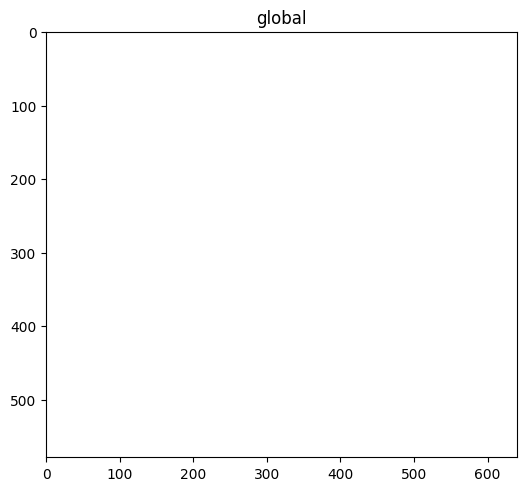

In [17]:
easy_vitessce.configure_plots(disable_plots = ["spatialdata-plot"])
sdata.pl.render_points('transcripts').pl.show()
easy_vitessce.configure_plots(enable_plots = ["spatialdata-plot"])

In [15]:
from napari_spatialdata import Interactive

In [16]:
Interactive(sdata)

2025-11-14 01:02:55.935 | WARNING  | napari_spatialdata._viewer:__init__:56 - Due to Shift-L being used as shortcut in napari, it is being deprecated and might not link a new layer to an existing SpatialData object in the viewer. Please use ⌘-L on MacOS or else Ctrl-L.


2025-11-14 01:03:04.231 | INFO     | napari_spatialdata._viewer:get_sdata_points:719 - Subsampling points because the number of points exceeds the currently supported 100000. You can change this threshold with ```from napari_spatialdata.constants import config
config.POINT_THRESHOLD = <new_threshold>```
2025-11-14 01:03:04.522 | DEBUG    | napari_spatialdata._view:_on_layer_update:569 - Updating layer.
2025-11-14 01:03:15.699 | DEBUG    | napari_spatialdata._view:_on_layer_update:569 - Updating layer.
2025-11-14 01:03:15.700 | DEBUG    | napari_spatialdata._view:_on_layer_update:569 - Updating layer.
2025-11-14 01:03:15.795 | DEBUG    | napari_spatialdata._view:_on_layer_update:569 - Updating layer.
